# 모델 양자화 (Quantization) - 실습 코드 2: 직접 구현: Min-Max / Affine 양자화

- Tutorial ID: `expand-quantization`
- Tutorial: 모델 양자화 (Quantization)
- Section ID: `expand-quantization-code-2`
- Section: 실습 코드 2: 직접 구현: Min-Max / Affine 양자화

> 📘 이 노트북은 원본 실습 코드를 초심자 눈높이에 맞춰 다시 정리한 버전입니다.
> 새로운 개념은 등장하기 전에 먼저 말로 설명하고, 아주 작은 숫자 예제로
> "손으로 계산하듯" 먼저 확인한 뒤에 일반적인 함수로 구현합니다.

## 시작하기 전에 — 양자화(Quantization)가 뭔가요?

딥러닝 모델의 가중치(weight)는 보통 **FP32(32비트 부동소수점, 4바이트)** 형식으로
저장됩니다. 파라미터가 70억 개(7B)인 모델이라면 대략 70억 × 4바이트 ≈ **28GB**의
메모리가 필요하다는 뜻이죠.

**양자화**는 이 숫자들을 더 적은 비트(예: INT8 = 8비트, INT4 = 4비트)로
"근사"해서 표현하는 기법입니다. 비유를 들어볼게요.

- FP32로 숫자를 저장하는 것 = **눈금이 아주 촘촘한 자**로 길이를 재는 것
  (예: 1.23456 cm 처럼 세밀하게 표현 가능)
- INT4로 저장하는 것 = **눈금이 굵은 자**로 재는 것
  (눈금이 굵어서 1.23456 cm를 재면 가장 가까운 눈금으로 "반올림"할 수밖에 없음)

눈금이 굵어질수록(=비트 수가 줄어들수록) 오차는 커지지만, 대신 이런 장점이 생깁니다.

| 장점 | 설명 |
|---|---|
| 메모리 절약 | FP32 → INT4는 이론상 8배 압축 (32bit ÷ 4bit) |
| 속도 향상 | 정수 연산이 하드웨어에서 더 빠르게 처리되는 경우가 많음 |
| 배포 용이성 | 더 적은 VRAM으로도 큰 모델을 로드/서빙할 수 있음 |

이번 실습에서는 라이브러리 뒤에 숨겨진 양자화 공식을 **직접 손으로, 그리고
코드로** 구현하면서 "정확히 어떤 계산이 일어나는지"를 이해하는 것이 목표입니다.
다룰 내용은 아래 3가지입니다.

1. **Min-Max 대칭(Symmetric) 양자화** — 가장 기본적인 방식. 0을 중심으로 좌우
   대칭인 범위를 사용합니다.
2. **Affine 비대칭(Asymmetric) 양자화** — 값이 한쪽으로 치우친 데이터(예: ReLU를
   지난 활성화 값)에 유리한 방식입니다.
3. **AWQ 스타일 중요 채널 보존 양자화** — 모든 weight를 동등하게 취급하지 않고,
   중요한 부분만 골라 정밀도를 높이는 방식입니다.

각 방법을 코드로 만나기 전에, 아주 작은 숫자 몇 개짜리 예제로 먼저 손 계산하듯
따라가 볼 거예요. 그다음 일반적인 함수로 옮기고, 마지막엔 실제 신경망 레이어와
비슷한 크기로 확장해서 방법들을 비교합니다.

In [1]:
# ============================================================
# 코드 읽는 법 — 실습 코드 2: 직접 구현: Min-Max / Affine 양자화
#
# 이 노트북은 "한 번 실행하고 끝"이 아니라, 양자화 공식이 실제 텐서 연산으로
# 어떻게 바뀌는지 한 줄씩 눈으로 따라가기 위한 실습 노트입니다.
#
# 학습 목표:
#   1) scale과 zero_point가 무엇이고, 어떤 계산으로 나오는지 손으로 계산해보며 이해하기
#   2) 대칭(Symmetric)과 비대칭(Affine) 양자화의 차이, 그리고 각각 언제 유리한지 알기
#   3) 양자화(quantize) -> 역양자화(dequantize) 과정에서 생기는 오차를 직접 측정해보기
#   4) 모든 weight를 똑같이 취급하지 않고, activation이 큰 채널만 선별해서
#      정밀도를 높이는 AWQ 스타일 아이디어를 코드로 구현해보기
#
# 읽는 순서:
#   1) 먼저 비트 수(n_bits)에 따라 표현 가능한 정수 범위가 어떻게 달라지는지 확인합니다.
#   2) 원소 5개짜리 아주 작은 텐서로 대칭/비대칭 양자화를 손으로 계산하듯 따라갑니다.
#   3) 손으로 계산한 결과와 함수로 구현한 결과가 정확히 일치하는지 검증합니다.
#   4) 실제 신경망 레이어 크기의 가중치 행렬로 확장해서, 방법별 오차·메모리를 비교합니다.
#   5) n_bits, alpha(중요 채널 비율) 같은 값을 바꿔가며 오차/메모리가 어떻게
#      달라지는지 직접 실험해봅니다.
#
# 주의:
#   - 숫자 하나하나를 외우기보다 "scale이 커지면 오차도 커진다"처럼 값들 사이의
#     관계와 방향성을 이해하는 데 집중하세요.
#   - 이 노트북은 torch / matplotlib만 사용하므로 Colab이나 로컬 환경 어디서든
#     바로 실행할 수 있습니다. (미설치 시: pip install torch matplotlib)
# ============================================================

In [2]:
# 노트북 안에서 그래프가 바로 보이도록 설정 (Jupyter/Colab 모두에서 필요한 표준 설정)
%matplotlib inline

import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 실습 결과를 항상 똑같이 재현하기 위해 랜덤 시드를 고정합니다.
# (시드를 고정하지 않으면 실행할 때마다 난수가 달라져서, 이 노트북에 적힌
#  설명 속 숫자와 실제 실행 결과가 달라질 수 있습니다)
torch.manual_seed(42)

# 그래프에 한글이 깨지지 않도록 폰트를 설정합니다.
# 실행 환경마다 설치된 한글 폰트 이름이 다를 수 있어서, 아래 후보 중 이
# 환경에 실제로 설치된 폰트를 자동으로 찾아 사용합니다.
#   - 'Noto Sans CJK JP' / 'Noto Sans CJK KR' : 리눅스 서버, 이 실습 환경
#   - 'NanumGothic'                            : Google Colab (설치: !apt -y install fonts-nanum)
#   - 'Malgun Gothic'                          : Windows
#   - 'AppleGothic'                            : macOS
korean_font_candidates = ['Noto Sans CJK KR', 'Noto Sans CJK JP', 'NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed_fonts = {f.name for f in fm.fontManager.ttflist}

for font_name in korean_font_candidates:
    if font_name in installed_fonts:
        plt.rcParams['font.family'] = font_name
        print(f"한글 폰트 설정 완료: {font_name}")
        break
else:
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글 라벨이 네모(뮤)로 보일 수 있습니다.")
    print("Colab이라면 아래 명령 실행 후 런타임을 재시작하세요:")
    print("  !apt -y install fonts-nanum && rm -rf ~/.cache/matplotlib")

plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호가 깨지는 것 방지

print("torch 버전:", torch.__version__)

한글 폰트 설정 완료: Noto Sans CJK JP
torch 버전: 2.12.1+cu130


## Step 0. 준비 운동 — 비트(bit) 수와 표현 범위

양자화 공식을 보기 전에, 먼저 "n비트로 정수를 표현한다"는 것이 정확히 무엇을
뜻하는지 짚고 넘어갈게요.

- **n비트**는 2ⁿ개의 서로 다른 값을 표현할 수 있다는 뜻입니다.
  (비트 하나가 0 또는 1, 두 가지 상태를 가지므로 n개를 조합하면 2ⁿ가지 경우의 수)
- 정수를 표현하는 방식은 크게 두 가지입니다.
  - **부호 있음(signed)**: 음수와 양수를 모두 표현. 범위는 `-2^(n-1) ~ 2^(n-1)-1`
    (예: int8 → **-128 ~ 127**)
  - **부호 없음(unsigned)**: 0과 양수만 표현. 범위는 `0 ~ 2^n - 1`
    (예: uint8 → **0 ~ 255**)

이번 실습에서 다룰 두 가지 양자화 방식은 이 두 범위를 각각 사용합니다.
- 대칭(Symmetric) 양자화 → **signed** 범위 사용 (0을 중심으로 좌우 대칭이니까요)
- 비대칭(Affine) 양자화 → **unsigned** 범위 사용 (0부터 시작하는 범위를 씀)

아래 코드에서 실제로 비트 수를 바꿔가며 범위가 어떻게 달라지는지 확인해봅시다.

In [3]:
print("=" * 55)
print("비트 수(n_bits)에 따른 표현 가능한 정수의 개수와 범위")
print("=" * 55)

for n_bits in [8, 4, 3, 2]:
    n_levels = 2 ** n_bits  # 표현 가능한 값의 총 개수

    # 부호 있는(signed) 범위: 예) 4bit -> -8 ~ 7
    signed_min = -(2 ** (n_bits - 1))
    signed_max = 2 ** (n_bits - 1) - 1

    # 부호 없는(unsigned) 범위: 예) 4bit -> 0 ~ 15
    unsigned_min = 0
    unsigned_max = 2 ** n_bits - 1

    print(f"\n[{n_bits}-bit] 표현 가능한 값의 개수 = 2^{n_bits} = {n_levels}개")
    print(f"   signed(부호 있음)   범위 : {signed_min:>5} ~ {signed_max:<5}  (대칭 양자화가 사용)")
    print(f"   unsigned(부호 없음) 범위 : {unsigned_min:>5} ~ {unsigned_max:<5}  (비대칭 양자화가 사용)")

print("\n" + "=" * 55)
print("FP32는 32bit를 모두 써서 훨씬 더 넓고 촘촘하게 표현하지만(대략")
print("±3.4×10^38, 소수점 포함), 4bit는 고작 16개의 '눈금'만 가진다는 걸")
print("기억해두세요. 이 16개의 눈금을 실수 범위 위에 어떻게 배치하느냐가")
print("이번 실습의 핵심입니다.")

비트 수(n_bits)에 따른 표현 가능한 정수의 개수와 범위

[8-bit] 표현 가능한 값의 개수 = 2^8 = 256개
   signed(부호 있음)   범위 :  -128 ~ 127    (대칭 양자화가 사용)
   unsigned(부호 없음) 범위 :     0 ~ 255    (비대칭 양자화가 사용)

[4-bit] 표현 가능한 값의 개수 = 2^4 = 16개
   signed(부호 있음)   범위 :    -8 ~ 7      (대칭 양자화가 사용)
   unsigned(부호 없음) 범위 :     0 ~ 15     (비대칭 양자화가 사용)

[3-bit] 표현 가능한 값의 개수 = 2^3 = 8개
   signed(부호 있음)   범위 :    -4 ~ 3      (대칭 양자화가 사용)
   unsigned(부호 없음) 범위 :     0 ~ 7      (비대칭 양자화가 사용)

[2-bit] 표현 가능한 값의 개수 = 2^2 = 4개
   signed(부호 있음)   범위 :    -2 ~ 1      (대칭 양자화가 사용)
   unsigned(부호 없음) 범위 :     0 ~ 3      (비대칭 양자화가 사용)

FP32는 32bit를 모두 써서 훨씬 더 넓고 촘촘하게 표현하지만(대략
±3.4×10^38, 소수점 포함), 4bit는 고작 16개의 '눈금'만 가진다는 걸
기억해두세요. 이 16개의 눈금을 실수 범위 위에 어떻게 배치하느냐가
이번 실습의 핵심입니다.


## Step 1. Min-Max 대칭(Symmetric) 양자화

**아이디어**: 데이터의 절댓값 중 최댓값(`max_val`)을 기준으로, 0을 중심으로
좌우가 대칭인 정수 범위에 실수 값을 매핑합니다.

핵심 용어부터 정리하겠습니다.

- **scale(스케일)**: "정수 눈금 한 칸이 실수 세계에서 얼마만큼의 크기인가"를
  나타내는 값입니다. 자(ruler)에 비유하면 눈금 사이의 간격이에요.
- **quantize(양자화)**: 실수 값을 scale로 나눠서 정수 눈금 위치로 바꾸는 과정
- **dequantize(역양자화)**: 양자화된 정수에 다시 scale을 곱해서 실수 근삿값으로
  복원하는 과정. 양자화는 정보 손실이 있는 변환이라, 역양자화해도 원본과
  완전히 똑같아지지는 않습니다. (이 차이가 바로 "양자화 오차"입니다)
- **clamp(클램프)**: 계산된 정수가 표현 가능한 범위를 벗어나면, 범위의
  최솟값/최댓값으로 잘라내는 것. (예: 4bit 범위가 -8~7인데 계산 결과가 9가
  나왔다면 7로 잘라냅니다)

### 계산 공식

```
scale = max(|tensor|) / (2^(n_bits-1) - 1)

quantized   = round(tensor / scale) 를 [-2^(n_bits-1), 2^(n_bits-1)-1] 범위로 clamp
dequantized = quantized × scale
```

말로 풀면 이렇습니다.
1. 데이터에서 절댓값이 가장 큰 값을 찾는다 (`max_val`)
2. 이 `max_val`이 정수 범위의 양(+)의 최댓값(예: 4bit면 7)에 대응하도록 `scale`을 정한다
3. 모든 값을 `scale`로 나누고 반올림하면, 정수 눈금 위의 위치(=양자화된 값)가 된다
4. 혹시 범위를 벗어나는 값이 있으면 clamp로 잘라준다
5. 다시 사용할 때는 정수 값에 `scale`을 곱해서 실수 근삿값(=역양자화된 값)으로 되돌린다

바로 아래에서, 숫자 5개짜리 아주 작은 예제로 이 다섯 단계를 하나씩 눈으로
확인해보겠습니다.

In [4]:
print("=" * 60)
print("[손으로 풀어보기] 대칭(Symmetric) 양자화, 4-bit 예제")
print("=" * 60)

# 아주 작은 가중치 텐서 하나를 준비합니다. 실전에서는 수백~수천 개 원소를 가진
# 큰 텐서를 다루지만, 계산 과정을 눈으로 따라가기 위해 5개짜리로 축소했습니다.
w_example = torch.tensor([-1.0, -0.45, 0.0, 0.3, 0.82])
n_bits = 4

print(f"\n원본 값 (FP32, 5개): {[round(x, 4) for x in w_example.tolist()]}")

# --- 1단계: scale(간격) 계산 ---
max_val = torch.max(torch.abs(w_example))
print(f"\n[1단계] 절댓값 중 최댓값(max_val) 찾기")
print(f"        max_val = {max_val.item()}")

n_pos_levels = 2 ** (n_bits - 1) - 1  # 4bit -> 2^3 - 1 = 7 (정수 범위의 양의 최댓값)
scale = max_val / n_pos_levels
print(f"\n[2단계] scale 계산 = max_val / (2^(n_bits-1)-1) = {max_val.item()} / {n_pos_levels}")
print(f"        scale = {scale.item():.6f}")
print(f"        (이 값이 정수 눈금 한 칸의 실제 '크기'입니다)")

# --- 2단계: 정수로 반올림 + clamp ---
raw = w_example / scale
print(f"\n[3단계] 각 값을 scale로 나누기 (값 / scale)")
print(f"        {[round(x, 4) for x in raw.tolist()]}")

rounded = torch.round(raw)
print(f"\n[4단계] 반올림해서 정수로 만들기")
print(f"        {rounded.tolist()}")

quantized = rounded.clamp(-(2 ** (n_bits - 1)), 2 ** (n_bits - 1) - 1)
print(f"\n[5단계] clamp로 범위 제한 ({-(2**(n_bits-1))} ~ {2**(n_bits-1)-1})")
print(f"        {quantized.tolist()}")
print(f"        (이 예제는 모든 값이 이미 범위 안에 있어 4단계 결과와 동일합니다)")

# --- 3단계: 역양자화 ---
dequantized = quantized * scale
print(f"\n[6단계] 역양자화 (quantized x scale)")
print(f"        {[round(x, 4) for x in dequantized.tolist()]}")

# --- 오차 확인 ---
error = (w_example - dequantized).abs()
print(f"\n[오차 확인] 원본 vs 역양자화 값 비교")
for orig, deq, err in zip(w_example.tolist(), dequantized.tolist(), error.tolist()):
    print(f"   원본 {orig:6.3f}   ->   역양자화 {deq:6.3f}    (오차 {err:.4f})")

print(f"\n평균 절대 오차(MAE) = {error.mean().item():.4f}")
print(f"\n참고: -1.0과 0.0은 정확히 그대로 복원됐죠? 이 값들이 우연히 '정수")
print(f"눈금' 위에 정확히 올라갔기 때문입니다. 반면 -0.45, 0.3, 0.82처럼")
print(f"눈금 사이에 있던 값들은 가장 가까운 눈금으로 반올림되면서 오차가")
print(f"발생했습니다.")

[손으로 풀어보기] 대칭(Symmetric) 양자화, 4-bit 예제

원본 값 (FP32, 5개): [-1.0, -0.45, 0.0, 0.3, 0.82]

[1단계] 절댓값 중 최댓값(max_val) 찾기
        max_val = 1.0

[2단계] scale 계산 = max_val / (2^(n_bits-1)-1) = 1.0 / 7
        scale = 0.142857
        (이 값이 정수 눈금 한 칸의 실제 '크기'입니다)

[3단계] 각 값을 scale로 나누기 (값 / scale)
        [-7.0, -3.15, 0.0, 2.1, 5.74]

[4단계] 반올림해서 정수로 만들기
        [-7.0, -3.0, 0.0, 2.0, 6.0]

[5단계] clamp로 범위 제한 (-8 ~ 7)
        [-7.0, -3.0, 0.0, 2.0, 6.0]
        (이 예제는 모든 값이 이미 범위 안에 있어 4단계 결과와 동일합니다)

[6단계] 역양자화 (quantized x scale)
        [-1.0, -0.4286, 0.0, 0.2857, 0.8571]

[오차 확인] 원본 vs 역양자화 값 비교
   원본 -1.000   ->   역양자화 -1.000    (오차 0.0000)
   원본 -0.450   ->   역양자화 -0.429    (오차 0.0214)
   원본  0.000   ->   역양자화  0.000    (오차 0.0000)
   원본  0.300   ->   역양자화  0.286    (오차 0.0143)
   원본  0.820   ->   역양자화  0.857    (오차 0.0371)

평균 절대 오차(MAE) = 0.0146

참고: -1.0과 0.0은 정확히 그대로 복원됐죠? 이 값들이 우연히 '정수
눈금' 위에 정확히 올라갔기 때문입니다. 반면 -0.45, 0.3, 0.82처럼
눈금 사이에 있던 값들은 가장 가까운 눈금으로 반올림되면서 오차가
발생했습니다.


In [5]:
def quantize_symmetric(tensor, n_bits=4):
    """
    Min-Max 대칭(Symmetric) 양자화

    위에서 손으로 계산해본 6단계를 그대로 함수로 옮긴 것입니다.
    0을 중심으로 좌우가 대칭인 정수 범위 [-(2^(b-1)), 2^(b-1)-1] 에
    실수 값을 매핑합니다.

    Args:
        tensor: 양자화할 실수(float) 텐서
        n_bits: 사용할 비트 수 (기본값 4bit)

    Returns:
        quantized:   정수 텐서 (실제로 저장/전송되는 값)
        dequantized: 다시 실수로 되돌린 값 (오차 확인 및 연산에 사용)
        scale:       정수 눈금 한 칸의 실제 크기
    """
    # 1) 데이터의 절댓값 중 최댓값을 구해서 대칭 범위의 기준으로 삼습니다.
    max_val = torch.max(torch.abs(tensor))

    # 2) scale = "정수 한 칸이 실수로 얼마인가"
    #    n_bits=4 이면 2^(4-1)-1 = 7 이므로, 정수 범위의 양의 최댓값(7)을
    #    실수 범위의 최댓값(max_val)에 맞춘다는 뜻입니다.
    scale = max_val / (2 ** (n_bits - 1) - 1)
    # (참고: tensor의 모든 원소가 0이면 max_val도 0이 되어 scale이 0이 되고,
    #  다음 줄에서 0으로 나누기 문제가 생깁니다. 실제 신경망의 weight는 거의
    #  항상 0이 아닌 값을 포함하므로 이 노트북에서는 별도 처리를 하지 않았습니다)

    # 3) 실수를 scale로 나눠 정수 인덱스로 변환 -> 반올림 -> 범위를 벗어나면 clamp
    quantized = torch.round(tensor / scale).clamp(
        -(2 ** (n_bits - 1)), 2 ** (n_bits - 1) - 1
    )

    # 4) 역양자화: 정수 인덱스에 scale을 다시 곱해서 실수 근삿값으로 복원
    dequantized = quantized * scale

    # int8 컨테이너에 담아 반환합니다. (PyTorch에는 int4라는 실제 자료형이 없어서,
    #  4bit로 '개념상' 양자화하더라도 담는 그릇은 int8을 빌려 씁니다. 진짜로 4bit
    #  만큼의 메모리만 쓰려면 값 2개를 int8 하나에 압축(packing)해야 하는데, 이
    #  노트북에서는 개념 이해에 집중하기 위해 packing은 다루지 않습니다)
    return quantized.to(torch.int8), dequantized, scale


# 검증: 함수로 구현한 결과가 위에서 손으로 계산한 것과 완전히 같은지 확인합니다.
q, dq, s = quantize_symmetric(w_example, n_bits=4)
print("함수로 계산한 역양자화 값 :", [round(x, 4) for x in dq.tolist()])
print("손으로 계산한 역양자화 값 :", [round(x, 4) for x in dequantized.tolist()])
print("두 결과가 완전히 같은가?   :", torch.allclose(dq, dequantized))

함수로 계산한 역양자화 값 : [-1.0, -0.4286, 0.0, 0.2857, 0.8571]
손으로 계산한 역양자화 값 : [-1.0, -0.4286, 0.0, 0.2857, 0.8571]
두 결과가 완전히 같은가?   : True


## Step 2. 왜 비대칭(Affine) 양자화가 필요할까?

방금 배운 대칭 양자화는 0을 중심으로 좌우가 똑같은 범위를 사용합니다. 그런데
실전에서는 값이 한쪽으로 치우친 데이터가 매우 흔합니다.

**대표적인 예: ReLU를 통과한 활성화(activation) 값들**
`ReLU(x) = max(0, x)` 이므로, 결과값은 항상 0 이상입니다. 즉 음수가 하나도 없습니다.

이런 데이터에 대칭 양자화를 적용하면 어떤 문제가 생길까요?
- 대칭 양자화는 정수 범위의 절반(음수 쪽, 예: 4bit라면 -8~-1)을 **한 번도
  쓰이지 않는 낭비 구간**으로 남겨둡니다.
- 데이터에 음수가 전혀 없으니, 음수 쪽 정수 눈금들은 어떤 실수 값과도
  대응되지 않기 때문이죠.
- 결과적으로 16개(4bit) 눈금 중 8개만 쓰고 나머지 8개는 버리는 셈이니,
  표현력의 절반을 낭비하는 것과 같습니다.

이 문제를 해결하는 것이 **비대칭(Affine, 어파인) 양자화**입니다. "0을 중심으로
대칭"이라는 제약을 버리고, 데이터의 실제 **최솟값(min)** 과 **최댓값(max)** 을
정수 범위의 양 끝에 맞추는 방식입니다.

이때 새로 등장하는 개념이 **zero_point(제로 포인트)** 입니다.
- 비대칭 양자화가 사용하는 정수 범위는 항상 0부터 시작합니다. (예: 4bit → 0~15)
- 그런데 실수 세계의 "0.0"이 이 정수 범위의 정확히 어느 지점에 대응하는지는
  데이터의 min/max에 따라 달라집니다.
- 이 **"실수 0.0에 대응하는 정수 위치"** 를 zero_point라고 부릅니다.

### 계산 공식

```
scale      = (max(tensor) - min(tensor)) / (2^n_bits - 1)
zero_point = round(-min(tensor) / scale)

quantized   = round(tensor/scale + zero_point) 를 [0, 2^n_bits - 1] 범위로 clamp
dequantized = (quantized - zero_point) × scale
```

대칭 양자화와 비교하면 딱 두 가지가 달라집니다.
1. scale을 구할 때 `max(|tensor|)` 대신 `max - min`(실제 데이터가 걸쳐 있는 폭)을 사용
2. 정수로 변환/복원할 때 `zero_point`를 더하고 빼는 단계가 추가됨

바로 아래에서 ReLU를 통과했다고 가정한 데이터로 손 계산을 해보고, 정말 비대칭
양자화가 대칭 양자화보다 오차가 작은지 직접 확인해보겠습니다.

In [6]:
print("=" * 60)
print("[손으로 풀어보기] 비대칭(Affine) 양자화, 4-bit 예제")
print("=" * 60)

# ReLU를 통과했다고 가정한, 모두 0 이상인 값들
a_example = torch.tensor([0.0, 0.1, 0.4, 0.9, 2.0])
n_bits = 4

print(f"\n원본 값 (모두 0 이상, ReLU 이후 activation이라고 가정): {[round(x, 4) for x in a_example.tolist()]}")

# --- 비교: 만약 대칭 양자화를 그대로 썼다면? ---
max_val_sym = torch.max(torch.abs(a_example))
scale_sym = max_val_sym / (2 ** (n_bits - 1) - 1)
print(f"\n[비교] 만약 이 데이터에 대칭 양자화를 쓴다면?")
print(f"       scale = {max_val_sym.item()} / 7 = {scale_sym.item():.4f}")
print(f"       표현 가능한 정수 범위는 -8~7(총 16단계)이지만, 데이터가 전부 0")
print(f"       이상이므로 -8~-1에 해당하는 8단계는 단 한 번도 쓰이지 않습니다.")

# --- 비대칭 양자화 1단계: min/max ---
min_val = a_example.min()
max_val = a_example.max()
print(f"\n[1단계] 최솟값과 최댓값 찾기")
print(f"        min_val = {min_val.item()},  max_val = {max_val.item()}")

# --- 2단계: scale ---
n_levels = 2 ** n_bits - 1  # 4bit -> 15 (unsigned 범위의 최댓값)
scale = (max_val - min_val) / n_levels
print(f"\n[2단계] scale 계산 = (max-min) / (2^n_bits-1) = ({max_val.item()}-{min_val.item()}) / {n_levels}")
print(f"        scale = {scale.item():.6f}")

# --- 3단계: zero_point ---
zero_point = torch.round(-min_val / scale)
print(f"\n[3단계] zero_point 계산 = round(-min_val/scale)")
print(f"        zero_point = {int(zero_point.item())}")  # int()로 감싸서 -0.0을 0으로 깔끔하게 표시
print(f"        (이 예제는 min_val이 0이라서 zero_point도 0이 되었습니다.")
print(f"         min_val이 음수였다면 zero_point는 0보다 큰 값이 됩니다 -")
print(f"         잠시 후 다른 예제로 이 경우도 확인해봅니다)")

# --- 4~6단계: 양자화 ---
raw = a_example / scale + zero_point
print(f"\n[4단계] (값/scale + zero_point) 계산")
print(f"        {[round(x, 4) for x in raw.tolist()]}")

rounded = torch.round(raw)
print(f"\n[5단계] 반올림")
print(f"        {rounded.tolist()}")

quantized = rounded.clamp(0, 2 ** n_bits - 1)
print(f"\n[6단계] clamp로 범위 제한 (0 ~ {2**n_bits-1})")
print(f"        {quantized.tolist()}")

# --- 7단계: 역양자화 ---
dequantized = (quantized - zero_point) * scale
print(f"\n[7단계] 역양자화 ((quantized - zero_point) x scale)")
print(f"        {[round(x, 4) for x in dequantized.tolist()]}")

error = (a_example - dequantized).abs()
print(f"\n평균 절대 오차(MAE) = {error.mean().item():.4f}")

# --- 최종 비교 ---
_, deq_sym_a, _ = quantize_symmetric(a_example, n_bits=4)
error_sym_a = (a_example - deq_sym_a).abs().mean().item()
error_aff_a = error.mean().item()
print(f"\n[최종 비교] 같은 데이터에 두 방식을 적용했을 때 오차")
print(f"   대칭(Symmetric) 양자화 MAE : {error_sym_a:.4f}")
print(f"   비대칭(Affine)  양자화 MAE : {error_aff_a:.4f}")
print(f"\n   -> 비대칭 양자화의 오차가 훨씬 작습니다! 0 이상으로 치우친 데이터에는")
print(f"      비대칭 양자화가 정수 범위 16단계를 낭비 없이 알뜰하게 쓰기 때문입니다.")

[손으로 풀어보기] 비대칭(Affine) 양자화, 4-bit 예제

원본 값 (모두 0 이상, ReLU 이후 activation이라고 가정): [0.0, 0.1, 0.4, 0.9, 2.0]

[비교] 만약 이 데이터에 대칭 양자화를 쓴다면?
       scale = 2.0 / 7 = 0.2857
       표현 가능한 정수 범위는 -8~7(총 16단계)이지만, 데이터가 전부 0
       이상이므로 -8~-1에 해당하는 8단계는 단 한 번도 쓰이지 않습니다.

[1단계] 최솟값과 최댓값 찾기
        min_val = 0.0,  max_val = 2.0

[2단계] scale 계산 = (max-min) / (2^n_bits-1) = (2.0-0.0) / 15
        scale = 0.133333

[3단계] zero_point 계산 = round(-min_val/scale)
        zero_point = 0
        (이 예제는 min_val이 0이라서 zero_point도 0이 되었습니다.
         min_val이 음수였다면 zero_point는 0보다 큰 값이 됩니다 -
         잠시 후 다른 예제로 이 경우도 확인해봅니다)

[4단계] (값/scale + zero_point) 계산
        [0.0, 0.75, 3.0, 6.75, 15.0]

[5단계] 반올림
        [0.0, 1.0, 3.0, 7.0, 15.0]

[6단계] clamp로 범위 제한 (0 ~ 15)
        [0.0, 1.0, 3.0, 7.0, 15.0]

[7단계] 역양자화 ((quantized - zero_point) x scale)
        [0.0, 0.1333, 0.4, 0.9333, 2.0]

평균 절대 오차(MAE) = 0.0133

[최종 비교] 같은 데이터에 두 방식을 적용했을 때 오차
   대칭(Symmetric) 양자화 MAE : 0.0514
   비대칭(Affine)  양자화 MAE : 0.0133


In [7]:
def quantize_affine(tensor, n_bits=4):
    """
    Min-Max 비대칭(Affine) 양자화

    데이터의 실제 [min, max] 구간을 정수 범위 [0, 2^n_bits - 1] 에 매핑합니다.
    대칭 양자화와 달리 0을 중심에 두지 않기 때문에, 실수 0.0이 정수 범위의
    어느 지점에 대응하는지를 나타내는 zero_point가 필요합니다.

    Args:
        tensor: 양자화할 실수 텐서
        n_bits: 비트 수

    Returns:
        quantized:   uint8 정수 텐서
        dequantized: 복원된 실수 값
        scale:       정수 한 칸의 실제 크기
        zero_point:  실수 0.0에 대응하는 정수 위치
    """
    min_val, max_val = tensor.min(), tensor.max()

    # scale: [min, max] 전체 구간을 (2^n_bits - 1)개의 칸으로 나눈 간격
    scale = (max_val - min_val) / (2 ** n_bits - 1)

    # zero_point: 실수 0.0이 양자화 후 어떤 정수가 되는지 미리 계산해 둡니다.
    # (아래 quantized 공식에 실수 0을 대입해보면 round(0/scale + zero_point)
    #  = zero_point가 되죠? zero_point는 바로 그 값을 미리 구해 놓은 것입니다)
    zero_point = torch.round(-min_val / scale)

    # 양자화: 값을 scale로 나눈 뒤 zero_point만큼 이동시키고 반올림, 범위를 벗어나면 clamp
    quantized = torch.round(tensor / scale + zero_point).clamp(0, 2 ** n_bits - 1)

    # 역양자화: zero_point를 다시 빼주고 scale을 곱해 실수로 복원
    dequantized = (quantized - zero_point) * scale

    return quantized.to(torch.uint8), dequantized, scale, zero_point


# 검증 1: 함수 결과가 위에서 손으로 계산한 것과 같은지 확인
q_a, dq_a, s_a, zp_a = quantize_affine(a_example, n_bits=4)
print("함수로 계산한 역양자화 값 :", [round(x, 4) for x in dq_a.tolist()])
print("손으로 계산한 역양자화 값 :", [round(x, 4) for x in dequantized.tolist()])
print("두 결과가 완전히 같은가?   :", torch.allclose(dq_a, dequantized))

# 검증 2: 이번엔 음수가 섞인 데이터로 zero_point가 0이 아닌 값이 되는 것을 확인
print("\n" + "-" * 55)
print("[추가 확인] 음수가 섞인 데이터라면 zero_point는 어떻게 달라질까?")
q_w, dq_w, s_w, zp_w = quantize_affine(w_example, n_bits=4)
print(f"w_example = {[round(x, 4) for x in w_example.tolist()]}  (최솟값이 음수, -1.0)")
print(f"zero_point = {int(zp_w.item())}   (0이 아닌 양수가 나옵니다!)")
print(f"역양자화 결과 = {[round(x, 4) for x in dq_w.tolist()]}")
error_w_aff = (w_example - dq_w).abs().mean().item()
print(f"MAE = {error_w_aff:.4f}")

함수로 계산한 역양자화 값 : [0.0, 0.1333, 0.4, 0.9333, 2.0]
손으로 계산한 역양자화 값 : [0.0, 0.1333, 0.4, 0.9333, 2.0]
두 결과가 완전히 같은가?   : True

-------------------------------------------------------
[추가 확인] 음수가 섞인 데이터라면 zero_point는 어떻게 달라질까?
w_example = [-1.0, -0.45, 0.0, 0.3, 0.82]  (최솟값이 음수, -1.0)
zero_point = 8   (0이 아닌 양수가 나옵니다!)
역양자화 결과 = [-0.9707, -0.4853, 0.0, 0.2427, 0.8493]
MAE = 0.0303


## 눈으로 직접 확인하기 — "계단 모양"이 되는 양자화

지금까지 숫자로 오차를 확인했다면, 이번엔 그래프로 확인해볼 차례입니다.
매끄러운 곡선을 양자화하면 어떤 모습이 될까요? 아래에서 원본 곡선과
INT8·INT4·INT2로 양자화한 곡선을 겹쳐 그려보겠습니다.

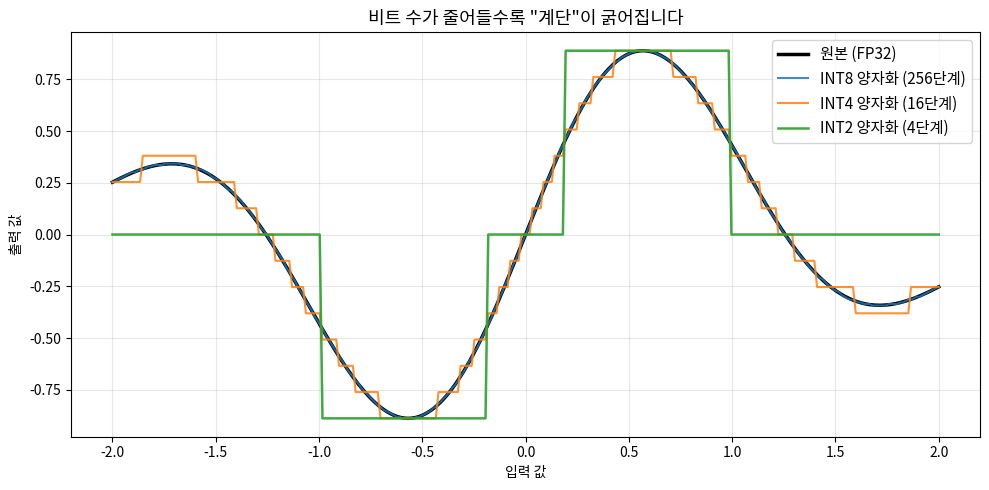

INT8은 원본과 거의 구별되지 않을 만큼 촘촘하지만,
INT4는 눈에 띄게 계단져 있고, INT2는 값이 단 4개뿐이라 원본 곡선의
형태를 거의 잃어버린 것을 확인할 수 있습니다.


In [8]:
# 매끄러운 곡선 하나를 만들어서, 양자화가 이 곡선을 어떻게 "계단 모양"으로
# 바꾸는지 눈으로 확인해봅니다.
x = torch.linspace(-2, 2, 300)
y = torch.sin(x * 2.5) * torch.exp(-x**2 / 3)  # 임의로 만든 매끄러운 곡선

_, y_int8, _ = quantize_symmetric(y, n_bits=8)
_, y_int4, _ = quantize_symmetric(y, n_bits=4)
_, y_int2, _ = quantize_symmetric(y, n_bits=2)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='원본 (FP32)', linewidth=2.5, color='black')
plt.plot(x, y_int8, label='INT8 양자화 (256단계)', linewidth=1.5, alpha=0.85)
plt.plot(x, y_int4, label='INT4 양자화 (16단계)', linewidth=1.5, alpha=0.85)
plt.plot(x, y_int2, label='INT2 양자화 (4단계)', linewidth=1.8, alpha=0.9)
plt.legend(fontsize=11)
plt.title('비트 수가 줄어들수록 "계단"이 굵어집니다', fontsize=13)
plt.xlabel('입력 값')
plt.ylabel('출력 값')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("INT8은 원본과 거의 구별되지 않을 만큼 촘촘하지만,")
print("INT4는 눈에 띄게 계단져 있고, INT2는 값이 단 4개뿐이라 원본 곡선의")
print("형태를 거의 잃어버린 것을 확인할 수 있습니다.")

## Step 3. 모든 weight가 똑같이 중요할까? — 중요 채널 보존 양자화

지금까지는 텐서 전체에 똑같은 비트 수를 적용했습니다. 그런데 실제 신경망에서는
weight 값 하나하나가 최종 출력에 미치는 영향이 서로 다릅니다.

핵심 아이디어를 이해하기 위해 `nn.Linear`(완전연결층)의 계산을 다시 떠올려봅시다.

```
출력(output) = 가중치(weight) @ 입력(activation)
```

이 식에서, 어떤 입력 채널(activation의 특정 위치)의 값이 유독 크다면, 그
채널과 곱해지는 weight의 작은 오차도 출력에 큰 영향을 미치게 됩니다. 반대로
입력 값이 항상 작은 채널이라면, 거기에 곱해지는 weight를 거칠게 양자화해도
출력에 미치는 영향은 미미합니다.

**AWQ(Activation-aware Weight Quantization)** 논문은 바로 이 관찰에서
출발합니다. "모든 weight를 동일한 정밀도로 양자화하지 말고, activation이 큰
채널에 연결된 weight는 더 높은 정밀도로 보존하자"는 것이 핵심 아이디어입니다.

> ⚠️ **주의**: 아래 구현은 AWQ의 핵심 아이디어(activation이 큰 채널을 더
> 신경 써서 보존한다)를 이해하기 쉽게 단순화한 예제입니다. 실제 AWQ 논문은
> 채널을 통째로 다른 비트로 양자화하는 대신, 채널별로 **최적의 스케일링 값**을
> 찾아서 모든 채널을 같은 비트 수로 양자화하면서도 오차를 줄이는 더 정교한
> 방법을 사용합니다. (비트 수 자체를 채널마다 다르게 쓰는 방식은 특수한
> 하드웨어 지원이 필요해서 실무에서는 흔치 않습니다) 여기서는 "중요도에 따라
> 다른 대우를 한다"는 개념을 직접 코드로 만져보는 데 집중합니다.

### weight 행렬에서 행(row)과 열(column), 무엇을 의미할까?

`nn.Linear(in_features, out_features)`의 weight는 `(out_features, in_features)`
모양입니다.

- **행(row)**: 출력 뉴런 하나에 대응 (예: 행이 256개면 출력은 256차원)
- **열(column)**: 입력 채널 하나에 대응 (예: 열이 512개면 입력은 512차원)

activation(입력)의 크기는 `(batch, in_features)`이므로, "입력 채널의 중요도"는
activation의 각 열(=각 입력 채널)에 대해 계산됩니다. 따라서 weight 행렬에서도
**열 단위**로 중요도를 적용해야 앞뒤가 맞습니다. (만약 행 단위로 적용한다면
입력 채널과 출력 뉴런을 혼동하는 것이므로 계산이 틀어집니다 — 아주 작은
예제로 바로 확인해보겠습니다)

In [9]:
print("=" * 60)
print("[손으로 풀어보기] 어떤 '채널'이 중요한지 확인하기")
print("=" * 60)

# 아주 작은 예: out_features=3, in_features=4 인 weight
tiny_weight = torch.tensor([
    [0.5, -0.2, 0.1, 0.9],
    [0.3,  0.4, -0.6, 0.2],
    [-0.1, 0.7, 0.2, -0.3],
])  # shape: (3, 4) = (out_features=3, in_features=4)

# activation: batch=2, in_features=4. index 2번(세 번째) 채널만 유독 값이 큽니다.
tiny_activation = torch.tensor([
    [0.1, 0.2, 5.0, 0.1],
    [0.2, 0.1, 4.8, 0.2],
])  # shape: (2, 4)

print(f"\nweight shape     : {tuple(tiny_weight.shape)}  (out_features=3, in_features=4)")
print(f"activation shape : {tuple(tiny_activation.shape)}  (batch=2, in_features=4)")

# 채널(=입력 feature)별 중요도: activation 절댓값을 batch 방향(dim=0)으로 평균
channel_importance = tiny_activation.abs().mean(dim=0)
print(f"\n채널별 중요도 (activation 절댓값의 평균): {[round(x, 4) for x in channel_importance.tolist()]}")
print(f"-> index 2번 채널(세 번째)이 유독 크죠? 이 채널에 연결된 weight의 '열'을")
print(f"   더 높은 정밀도로 보존해야 한다는 것이 AWQ의 핵심 아이디어입니다.")

threshold = torch.quantile(channel_importance, 0.5)
mask = channel_importance > threshold
print(f"\nthreshold(중앙값, 50% 분위수) = {threshold.item():.3f}")
print(f"중요 채널 마스크(중요도 > threshold): {mask.tolist()}")

important_idx = [i for i, m in enumerate(mask.tolist()) if m]
print(f"-> index {important_idx}만 True로 표시되었습니다.")

print(f"\n이 채널에 연결된 weight의 '열'(column)은 다음과 같습니다:")
for i in important_idx:
    print(f"  weight[:, {i}] = {[round(x, 4) for x in tiny_weight[:, i].tolist()]}  <- 모든 행(row)의 {i+1}번째 값들")
print(f"이 값들이 잠시 후 만들 함수에서 8bit로 정밀하게 보존되는 대상입니다.")

[손으로 풀어보기] 어떤 '채널'이 중요한지 확인하기

weight shape     : (3, 4)  (out_features=3, in_features=4)
activation shape : (2, 4)  (batch=2, in_features=4)

채널별 중요도 (activation 절댓값의 평균): [0.15, 0.15, 4.9, 0.15]
-> index 2번 채널(세 번째)이 유독 크죠? 이 채널에 연결된 weight의 '열'을
   더 높은 정밀도로 보존해야 한다는 것이 AWQ의 핵심 아이디어입니다.

threshold(중앙값, 50% 분위수) = 0.150
중요 채널 마스크(중요도 > threshold): [False, False, True, False]
-> index [2]만 True로 표시되었습니다.

이 채널에 연결된 weight의 '열'(column)은 다음과 같습니다:
  weight[:, 2] = [0.1, -0.6, 0.2]  <- 모든 행(row)의 3번째 값들
이 값들이 잠시 후 만들 함수에서 8bit로 정밀하게 보존되는 대상입니다.


In [10]:
def quantize_awq_style(weight, activation, n_bits=4, high_bits=8, alpha=0.9):
    """
    AWQ 스타일: activation 크기가 큰 입력 채널(weight의 '열')은 높은 정밀도로 보존

    Args:
        weight:     (out_features, in_features) 모양의 가중치 행렬
        activation: (batch, in_features) 모양의 입력 activation
        n_bits:     '덜 중요한' 채널에 사용할 비트 수 (기본 4bit)
        high_bits:  '중요한' 채널에 사용할 비트 수 (기본 8bit)
        alpha:      상위 몇 %를 '중요 채널'로 볼지 정하는 분위수(0~1 사이 값).
                    0.9면 activation 크기가 상위 10%인 채널만 중요 채널로 봅니다.

    Returns:
        weight_quantized: 채널별로 다른 정밀도로 양자화한 뒤 복원한 가중치
        important_mask:   각 입력 채널이 '중요 채널'인지 여부(True/False).
                           길이는 in_features와 같습니다.
    """
    # 1) 입력 채널(열)별 중요도 계산
    #    activation은 (batch, in_features) 모양이므로, batch 차원(dim=0)에 대해
    #    평균을 내면 "각 입력 채널이 평균적으로 얼마나 큰 값을 갖는지"를 구할 수 있습니다.
    channel_importance = activation.abs().mean(dim=0)  # shape: (in_features,)

    # 2) 중요도의 상위 (1-alpha) 비율을 '중요 채널'로 표시
    #    예: alpha=0.9 -> 중요도가 상위 10%에 드는 채널만 True
    threshold = torch.quantile(channel_importance, alpha)
    important_mask = channel_importance > threshold  # shape: (in_features,)

    weight_quantized = weight.clone()

    # 3) weight의 '열(column)' 단위로 순회합니다.
    #    weight.shape[1] == in_features == activation의 채널 수 이기 때문에,
    #    반드시 행(row)이 아니라 열 방향으로 순회해야 activation의 채널과
    #    올바르게 짝지어집니다. (바로 위 Step 3 설명에서 짚었던 부분입니다)
    for i in range(weight.shape[1]):
        column = weight[:, i:i+1]  # i번째 입력 채널에 연결된 모든 weight, shape: (out_features, 1)

        if important_mask[i]:
            # 중요한 채널: high_bits(기본 8bit)로 정밀하게 양자화
            _, deq_column, _ = quantize_symmetric(column, n_bits=high_bits)
        else:
            # 덜 중요한 채널: n_bits(기본 4bit)로 거칠게 양자화 (메모리 절약)
            _, deq_column, _ = quantize_symmetric(column, n_bits=n_bits)

        weight_quantized[:, i] = deq_column.squeeze()

    return weight_quantized, important_mask


def compute_awq_memory(weight_shape, important_mask, n_bits=4, high_bits=8):
    """
    AWQ 스타일 양자화가 실제로 차지하는 메모리(MB)를 계산합니다.
    (중요 채널과 일반 채널이 서로 다른 비트를 쓰기 때문에, 단순히
     '원소 개수 x 1개 비트 수'로 계산할 수 없어 별도 함수로 분리했습니다)
    """
    out_features, in_features = weight_shape
    n_important = important_mask.sum().item()
    n_normal = in_features - n_important

    # 열 하나를 저장하는 데 필요한 바이트 수 = (out_features x 비트수) / 8
    bytes_important = n_important * out_features * high_bits / 8
    bytes_normal = n_normal * out_features * n_bits / 8
    total_bytes = bytes_important + bytes_normal
    return total_bytes / 1e6  # MB 단위로 변환


# 검증: 아주 작은 예제(tiny_weight, tiny_activation)로 실제 동작 확인
tiny_deq, tiny_mask = quantize_awq_style(tiny_weight, tiny_activation, n_bits=4, high_bits=8, alpha=0.5)
print("중요 채널 마스크:", tiny_mask.tolist())
print("\n원본 weight:\n", tiny_weight)
print("\nAWQ 스타일로 양자화 후 복원한 weight:\n", tiny_deq)
print("\n(중요 채널로 표시된 열은 8bit로 양자화되어 원본과 거의 같고, 나머지")
print(" 열은 4bit라 오차가 좀 더 큰 것을 두 행렬을 비교해서 확인할 수 있습니다)")

중요 채널 마스크: [False, False, True, False]

원본 weight:
 tensor([[ 0.5000, -0.2000,  0.1000,  0.9000],
        [ 0.3000,  0.4000, -0.6000,  0.2000],
        [-0.1000,  0.7000,  0.2000, -0.3000]])

AWQ 스타일로 양자화 후 복원한 weight:
 tensor([[ 0.5000, -0.2000,  0.0992,  0.9000],
        [ 0.2857,  0.4000, -0.6000,  0.2571],
        [-0.0714,  0.7000,  0.1984, -0.2571]])

(중요 채널로 표시된 열은 8bit로 양자화되어 원본과 거의 같고, 나머지
 열은 4bit라 오차가 좀 더 큰 것을 두 행렬을 비교해서 확인할 수 있습니다)


### 잠깐 — 용어 확인: MAE와 MSE

지금까지 오차를 잴 때 `(원본 - 복원값).abs().mean()`, 즉 **오차의 절댓값을
평균**낸 값을 사용했습니다. 이 지표의 정확한 이름은 **MAE(Mean Absolute
Error, 평균절대오차)** 입니다.

비슷하지만 다른 지표로 **MSE(Mean Squared Error, 평균제곱오차)** 가 있는데,
이것은 절댓값 대신 **오차를 제곱**해서 평균을 냅니다
(`(원본 - 복원값).pow(2).mean()`). MSE는 큰 오차에 더 민감하게 반응한다는
차이가 있습니다. (오차가 2배가 되면 MSE는 4배로 커집니다)

이 노트북에서는 계산하는 그대로 **MAE**라는 이름을 사용하겠습니다.

## 종합 실험 — 실제 신경망 레이어 크기로 네 가지 방법 비교하기

이제 지금까지 만든 세 가지 양자화 방법(대칭, 비대칭, AWQ 스타일)을 실제
신경망 레이어와 비슷한 크기의 가중치 행렬에 적용해서 오차와 메모리를 함께
비교해보겠습니다.

- weight: `(256, 512)` 크기 (256개의 출력 뉴런, 512개의 입력 채널)
- activation: `(1, 512)` 크기 (weight에 들어가는 입력값 1개 샘플)

AWQ 스타일에서는 `alpha=0.9`를 사용해서, activation 중요도가 **상위 10%인
채널만** 8bit로 보존하고 나머지 90%는 4bit로 양자화합니다. (앞의 작은
예제에서는 이해를 돕기 위해 상위 50%를 보존했지만, 실전에서는 이렇게 일부
채널만 정밀하게 보존하는 것이 AWQ의 핵심입니다 — "작은 메모리 추가로 큰
오차 감소"를 얻는 것이 목표이기 때문입니다)

In [11]:
print("=" * 60)
print("종합 실험: 양자화 방법별 오차와 메모리 비교")
print("=" * 60)

torch.manual_seed(42)  # 앞서 4번째 셀에서 이미 고정했지만, 이 실험만 따로 다시
                       # 실행해도 항상 같은 결과가 나오도록 한 번 더 고정합니다.
weight = torch.randn(256, 512) * 0.5   # 실제 신경망 레이어 정도 크기의 가중치 행렬
activation = torch.randn(1, 512)        # 이 weight에 입력으로 들어가는 activation

original_mem = weight.numel() * 4 / 1e6  # FP32는 원소 하나당 4바이트
print(f"\n원본 FP32        : 메모리 {original_mem:.4f} MB  (비교 기준, 오차는 항상 0)")

# --- INT8 대칭 ---
_, deq_8, _ = quantize_symmetric(weight, n_bits=8)
error_8 = (weight - deq_8).abs().mean().item()
mem_8 = weight.numel() * 8 / 8 / 1e6  # 8bit = 1byte
print(f"INT8 대칭         : MAE {error_8:.6f}  메모리 {mem_8:.4f} MB  ({original_mem/mem_8:.1f}배 압축)")

# --- INT4 대칭 ---
_, deq_4, _ = quantize_symmetric(weight, n_bits=4)
error_4 = (weight - deq_4).abs().mean().item()
mem_4 = weight.numel() * 4 / 8 / 1e6  # 4bit = 0.5byte
print(f"INT4 대칭         : MAE {error_4:.6f}  메모리 {mem_4:.4f} MB  ({original_mem/mem_4:.1f}배 압축)")

# --- INT4 비대칭 ---
_, deq_aff, _, _ = quantize_affine(weight, n_bits=4)
error_aff = (weight - deq_aff).abs().mean().item()
print(f"INT4 비대칭       : MAE {error_aff:.6f}  메모리 {mem_4:.4f} MB  ({original_mem/mem_4:.1f}배 압축)")

# --- AWQ 스타일 (상위 10% 채널만 8bit로 보존, 나머지는 4bit) ---
deq_awq, mask = quantize_awq_style(weight, activation, n_bits=4, high_bits=8, alpha=0.9)
error_awq = (weight - deq_awq).abs().mean().item()
mem_awq = compute_awq_memory(weight.shape, mask, n_bits=4, high_bits=8)
print(f"AWQ 스타일        : MAE {error_awq:.6f}  메모리 {mem_awq:.4f} MB  ({original_mem/mem_awq:.1f}배 압축)")
print(f"                    (중요 채널 {mask.sum().item()}/{len(mask)}개를 8bit로 보존)")

print("\n" + "-" * 60)
print("[해석]")
mem_increase = (mem_awq / mem_4 - 1) * 100
error_decrease = (1 - error_awq / error_4) * 100
print(f"- AWQ 스타일은 INT4 대칭 대비 메모리를 {mem_increase:.1f}%만 더 쓰면서")
print(f"  (겨우 {mask.sum().item()}개 채널만 8bit로 바꿨을 뿐인데도)")
print(f"  오차(MAE)는 {error_decrease:.1f}%나 줄였습니다.")
print(f"- 이것이 '모두를 조금씩 아끼기보다, 중요한 일부만 더 신경 쓴다'는")
print(f"  AWQ 전략의 핵심 장점입니다.")

종합 실험: 양자화 방법별 오차와 메모리 비교

원본 FP32        : 메모리 0.5243 MB  (비교 기준, 오차는 항상 0)
INT8 대칭         : MAE 0.004568  메모리 0.1311 MB  (4.0배 압축)
INT4 대칭         : MAE 0.082636  메모리 0.0655 MB  (8.0배 압축)
INT4 비대칭       : MAE 0.076864  메모리 0.0655 MB  (8.0배 압축)
AWQ 스타일        : MAE 0.048888  메모리 0.0722 MB  (7.3배 압축)
                    (중요 채널 52/512개를 8bit로 보존)

------------------------------------------------------------
[해석]
- AWQ 스타일은 INT4 대칭 대비 메모리를 10.2%만 더 쓰면서
  (겨우 52개 채널만 8bit로 바꿨을 뿐인데도)
  오차(MAE)는 40.8%나 줄였습니다.
- 이것이 '모두를 조금씩 아끼기보다, 중요한 일부만 더 신경 쓴다'는
  AWQ 전략의 핵심 장점입니다.


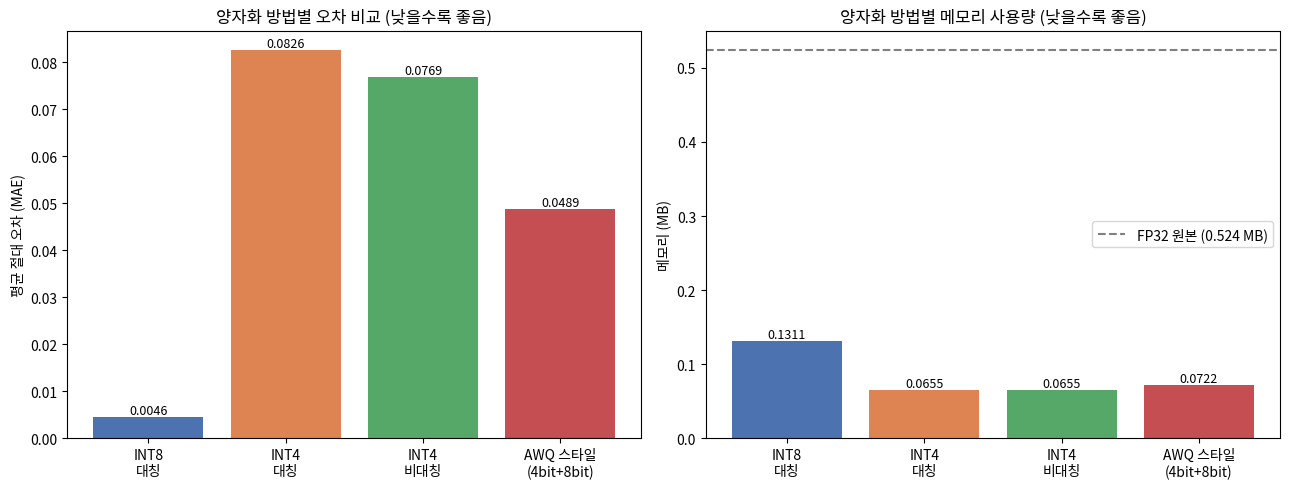

왼쪽 그래프: AWQ 스타일이 INT4 계열 중 가장 낮은 오차를 보입니다.
오른쪽 그래프: 그런데도 메모리는 INT4와 거의 비슷한 수준(살짝만 높음)
입니다. '적은 비용으로 큰 효과'를 얻는 모습을 그래프로도 확인할 수 있습니다.


In [12]:
methods = ['INT8\n대칭', 'INT4\n대칭', 'INT4\n비대칭', 'AWQ 스타일\n(4bit+8bit)']
errors = [error_8, error_4, error_aff, error_awq]
memories = [mem_8, mem_4, mem_4, mem_awq]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
x_pos = list(range(len(methods)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 오차 비교
axes[0].bar(x_pos, errors, color=colors)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel('평균 절대 오차 (MAE)')
axes[0].set_title('양자화 방법별 오차 비교 (낮을수록 좋음)')
for i, v in enumerate(errors):
    axes[0].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# 오른쪽: 메모리 비교
axes[1].bar(x_pos, memories, color=colors)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods)
axes[1].axhline(y=original_mem, color='gray', linestyle='--',
                 label=f'FP32 원본 ({original_mem:.3f} MB)')
axes[1].set_ylabel('메모리 (MB)')
axes[1].set_title('양자화 방법별 메모리 사용량 (낮을수록 좋음)')
axes[1].legend()
for i, v in enumerate(memories):
    axes[1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("왼쪽 그래프: AWQ 스타일이 INT4 계열 중 가장 낮은 오차를 보입니다.")
print("오른쪽 그래프: 그런데도 메모리는 INT4와 거의 비슷한 수준(살짝만 높음)")
print("입니다. '적은 비용으로 큰 효과'를 얻는 모습을 그래프로도 확인할 수 있습니다.")

## 정리

이번 실습에서 구현한 세 가지 양자화 방법을 표로 정리하면 다음과 같습니다.

| 방법 | 매핑 대상 범위 | 핵심 파라미터 | 잘 맞는 상황 |
|---|---|---|---|
| Min-Max 대칭(Symmetric) | `[-max\|x\|, max\|x\|]` → signed 정수 | scale | 값이 0을 중심으로 고르게 분포할 때 |
| Affine 비대칭(Asymmetric) | `[min, max]` → unsigned 정수 | scale, zero_point | 값이 한쪽으로 치우쳤을 때 (예: ReLU 이후 activation) |
| AWQ 스타일 | 채널별로 다른 정밀도 적용 | scale, 중요 채널 마스크 | 채널마다 중요도가 크게 다를 때 |

**이번 실습에서 직접 확인한 것들**

1. 비트 수(n_bits)가 줄어들수록 표현 가능한 눈금 개수가 줄어들고, 오차는 커집니다.
2. 대칭 양자화는 구현이 간단하지만, 데이터가 한쪽으로 치우쳐 있으면 정수
   범위의 절반을 낭비할 수 있습니다.
3. 비대칭 양자화는 zero_point를 도입해서 이 낭비를 줄이고, 치우친 데이터에
   대해 더 낮은 오차를 냅니다.
4. 모든 weight를 똑같이 취급하는 대신, activation이 큰 채널만 선별해서
   정밀도를 높이면(AWQ 스타일) 메모리를 조금만 더 쓰고도 오차를 크게 줄일
   수 있습니다.

**다음 단계로 시도해볼 것들**

- `n_bits`를 2, 3, 6 등으로 바꿔가며 오차가 어떻게 변하는지 관찰해보기
- `alpha` 값을 0.5, 0.8, 0.95 등으로 바꿔가며 "중요 채널 비율 vs 오차"의
  관계를 그래프로 그려보기
- `torch.randn` 대신 실제로 ReLU를 통과시킨 activation으로 실험해보고,
  비대칭 양자화가 얼마나 더 유리해지는지 확인해보기
- (심화) weight 값 2개를 int8 하나에 압축(bit packing)해서, 4bit 양자화가
  정말로 메모리를 절반으로 줄이는지 직접 구현해보기